Histograms and Scatter Plots to Analyze Clustering Betweeen Particle Types

In [1]:
# imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import h5py

import matplotlib.pyplot as plt
import seaborn as sns

import re
# env confirmation
print("Python executable:", sys.executable)

# plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Setup complete.")


Python executable: /Users/k92/clustering_env/bin/python
Setup complete.


In [3]:
#verify imports real quick
import numpy
import pandas
import h5py
import matplotlib
import seaborn
from pathlib import Path

print("All imports successful.")


All imports successful.


In [4]:
# set where hdf5 files live in order to loop through for plotting
# assumes they live within this Allpix2ClusteringExamples/Metrics/....
# ./metrics/metrics_<particle>_<energy><unit>.h5

metrics_dir = Path("./metrics")

# filename convention
FNAME_RE = re.compile(r"^metrics_(.+)_(\d+)(keV|MeV|GeV)\.h5$")

def parse_run_name(fname: str):
    """
    Returns: (particle: str, energy_keV: float) or (None, None) if not matched.
    """
    m = FNAME_RE.match(fname)
    if not m:
        return None, None
    particle, energy, unit = m.groups()
    energy = float(energy)
    if unit == "MeV":
        energy *= 1e3
    elif unit == "GeV":
        energy *= 1e6
    return particle, energy

print("Metrics folder:", metrics_dir.resolve())
print("Expected naming: metrics_<particle>_<energy><unit>.h5")
print("Example:", "metrics_gamma_50keV.h5")


Metrics folder: /Users/k92/Allpix2ClusteringExample/metrics
Expected naming: metrics_<particle>_<energy><unit>.h5
Example: metrics_gamma_50keV.h5


In [5]:
# parse particle type and energy from file names
# particle: string (e.g., "alpha", "proton", "muon-", "gamma", "muon+")
# energy_keV: int (everything converted to keV)
# run_id: string for plotting/grouping (e.g., "alpha_100keV")

UNIT_TO_KEV = {"keV": 1, "MeV": 1_000, "GeV": 1_000_000}

def parse_energy_to_keV(text: str):
    """
    Parse strings like: '10keV', '1MeV', '2GeV' -> energy_keV (int)
    Returns (energy_keV, unit) or (None, None) if not parseable.
    """
    m = re.match(r"^\s*(\d+)\s*(keV|MeV|GeV)\s*$", text)
    if not m:
        return None, None
    val = int(m.group(1))
    unit = m.group(2)
    return val * UNIT_TO_KEV[unit], unit

def parse_run_from_folder(folder_name: str):
    """
    returns dict with particle, energy_keV, energy_text, run_id
    """
    m = re.match(r"^(?P<particle>.+)_(?P<energy>\d+(keV|MeV|GeV))$", folder_name)
    if not m:
        return None

    particle = m.group("particle")
    energy_text = m.group("energy")
    energy_keV, unit = parse_energy_to_keV(energy_text)
    if energy_keV is None:
        return None

    run_id = f"{particle}_{energy_text}"  #
    return {
        "particle": particle,
        "energy_keV": energy_keV,
        "energy_text": energy_text,
        "run_id": run_id,
    }

def parse_run_from_metrics_filename(fname: str):
    """
    Returns same dict as parse_run_from_folder.
    """
    m = re.match(r"^metrics_(?P<particle>.+)_(?P<energy>\d+(keV|MeV|GeV))\.h5$", fname)
    if not m:
        return None

    particle = m.group("particle")
    energy_text = m.group("energy")
    energy_keV, unit = parse_energy_to_keV(energy_text)
    if energy_keV is None:
        return None

    run_id = f"{particle}_{energy_text}"
    return {
        "particle": particle,
        "energy_keV": energy_keV,
        "energy_text": energy_text,
        "run_id": run_id,
    }

print("run parsing helpers ready.")


run parsing helpers ready.


In [6]:
#load all hdf5

# set this to wherever i decide to put my metric files
metrics_dir = Path("./metrics")

# they will all start with metrics so this will search for all HDF5 files that start with "metrics_"
# assumes: metrics_<particle>_<energy><unit>.h5
files = sorted(metrics_dir.glob("metrics_*.h5"))

print("Found files:")
for f in files:
    print("  ", f.name)

def parse_filename(fname):
    """
    Extract particle and energy (in keV) from filename.
    """
    pattern = r"metrics_(.+)_(\d+)(keV|MeV|GeV)\.h5"
    match = re.match(pattern, fname)

    if not match:
        return None, None

    particle, energy, unit = match.groups()
    energy = float(energy)

    # convert to keV
    if unit == "MeV":
        energy *= 1e3
    elif unit == "GeV":
        energy *= 1e6

    return particle, energy

# combines allllll files 
all_runs = []

for file in files:
    particle, energy_keV = parse_filename(file.name)

    if particle is None:
        print(f"Skipping {file.name} (name not recognized)")
        continue

    with h5py.File(file, "r") as f:
        dset = f["clusters"]
        data_array = dset[:]
        columns = list(dset.attrs["columns"])

    df = pd.DataFrame(data_array, columns=columns)

    # add labels
    df["particle"] = particle
    df["energy_keV"] = energy_keV
    df["run"] = file.stem

    all_runs.append(df)

# master table ---- can print, but will have thousands of columns for all the clusters in allll the runs
data = pd.concat(all_runs, ignore_index=True)


Found files:
   metrics_alpha_10MeV.h5
   metrics_electron_100keV.h5
   metrics_gamma_10keV.h5
   metrics_muminus_500keV.h5
   metrics_muplus_500keV.h5
   metrics_proton_100MeV.h5


In [7]:
#charge to energy
# Q_cluster is total electrons per cluster (sum of |charge| per pixel)
# Silicon: ~3.6 eV per electron-hole pair
EV_PER_EH = 3.64

# Convert electrons -> keV and MeV
data["E_cluster_keV"] = data["Q_cluster"] * EV_PER_EH / 1000.0
# per-cluster "energy density" 
data["energy_density"] = data["E_cluster_keV"] / data["n_hits"].replace(0, np.nan)
#get rid of all Q_cluster
#data.drop(columns=["Q_cluster"], inplace=True)

In [8]:
# ------------------- SINGLE-RUN CLUSTER INSPECTOR -------------------
# Purpose: pick ONE run and inspect the cluster-level metrics (rows = clusters)

# choose run to inspect (must match values in data["run"])
SELECT_ONE_RUN = "metrics_gamma_10keV"   #change this depending on the singular run you want to evaluate

# 2) pick which cluster-level columns you want to print (edit as you like)
# print only columns that actually exist in your dataset.
CLUSTER_METRICS_TO_SHOW = [
    "event",     
    "n_hits",
    "E_cluster_keV",
    "bbox_area",
    "fill_factor",
    "cx", "cy",
    "mean_r", "rms_r", "r90",
    "axis_asym", "axis_skew",
    "neighbor_frac",
    "skew_skipped",   
]

# 3) filter to that run (DOES NOT overwrite the master data unless you want it to)
run_df = data[data["run"] == SELECT_ONE_RUN].copy()

print("Single-run selection:", SELECT_ONE_RUN)
print("Clusters in run:", len(run_df))
print("Particle(s) in run:", sorted(run_df["particle"].unique()))
print("Energy_keV in run:", sorted(run_df["energy_keV"].unique()))

if run_df.empty:
    print("\nWARNING: No rows found for that run name.")
else:
    # keep only columns that exist
    cols_present = [c for c in CLUSTER_METRICS_TO_SHOW if c in run_df.columns]
    cols_missing = [c for c in CLUSTER_METRICS_TO_SHOW if c not in run_df.columns]

    if cols_missing:
        print("\nNote: these requested columns are not in this dataset and will be skipped:")
        print("  ", cols_missing)

    # snapshot of the cluster table 
    display(run_df[cols_present].head(30)) #can change the # of rorws allowed

Single-run selection: metrics_gamma_10keV
Clusters in run: 86700
Particle(s) in run: ['gamma']
Energy_keV in run: [np.float64(10.0)]


,event,n_hits,E_cluster_keV,bbox_area,fill_factor,cx,cy,mean_r,rms_r,r90,axis_asym,axis_skew,neighbor_frac,skew_skipped
99402,0.0,2.0,9.66420,2.0,1.0,170.453861,245.000000,0.5,0.502124,0.536911,0.0,NaN,1.0,1.0
99403,1.0,1.0,8.69596,1.0,1.0,70.000000,55.000000,0.0,0.000000,0.000000,0.0,NaN,0.0,1.0
99404,2.0,1.0,9.98088,1.0,1.0,91.000000,207.000000,0.0,0.000000,0.000000,0.0,NaN,0.0,1.0
99405,3.0,2.0,9.90808,2.0,1.0,288.745775,258.000000,0.5,0.557140,0.696620,0.0,NaN,1.0,1.0
99406,4.0,1.0,8.87068,1.0,1.0,172.000000,102.000000,0.0,0.000000,0.000000,0.0,NaN,0.0,1.0
99407,5.0,1.0,9.95904,1.0,1.0,50.000000,112.000000,0.0,0.000000,0.000000,0.0,NaN,0.0,1.0
99408,6.0,2.0,10.07916,2.0,1.0,106.000000,467.702059,0.5,0.539284,0.661647,0.0,NaN,1.0,1.0
99409,7.0,2.0,9.64236,2.0,1.0,363.000000,379.588524,0.5,0.507776,0.570819,0.0,NaN,1.0,1.0
99410,8.0,2.0,10.11192,2.0,1.0,444.000000,474.777178,0.5,0.571688,0.721742,0.0,NaN,1.0,1.0
99411,9.0,2.0,9.16188,2.0,1.0,72.590783,48.000000,0.5,0.508175,0.572626,0.0,NaN,1.0,1.0


In [8]:
# selection- can opt to only analyze spcific runs, can choose "all", "particles", "pairs", or "runs"
# creates:
#   data_all = full dataset (keep)
#   data     = filtered dataset (use for all later cells)

data_all = data.copy()

# ------------------- CHOOSE ONE MODE -------------------


MODE = "all"          

# option A: choose particles type
SELECT_PARTICLES = ["alpha", "gamma"]     # e.g. ["alpha"] 

# option B: choose specific (particle, energy_keV) pairs
# remember: it has all been converted to keV so 1 MeV = 1000 keV, 10 MeV = 10000 keV, 1 GeV = 1_000_000 keV !!!
SELECT_PAIRS = [
    ("gamma", 10),
    ("alpha", 1000),
    ("proton", 10_000),
    ("electron", 100),
]

# option C: choose specific runs by filename 
SELECT_RUNS = [
    # "metrics_gamma_10keV",
    # "metrics_alpha_1MeV",
]

# filter applied here
if MODE == "all":
    data = data_all.copy()

elif MODE == "particles":
    data = data_all[data_all["particle"].isin(SELECT_PARTICLES)].copy()

elif MODE == "pairs":
    mask = False
    for p, e in SELECT_PAIRS:
        mask = mask | ((data_all["particle"] == p) & (data_all["energy_keV"] == e))
    data = data_all[mask].copy()

elif MODE == "runs":
    data = data_all[data_all["run"].isin(SELECT_RUNS)].copy()

else:
    raise ValueError(f"Unknown MODE: {MODE}")

# summary
print("Selection MODE:", MODE)
print("Selected shape:", data.shape)
print("Selected particles:", sorted(data["particle"].unique()))
print("Selected runs:", sorted(data["run"].unique())[:15]) #can limit to only first x amount of runs


Selection MODE: all
Selected shape: (411421, 22)
Selected particles: ['alpha', 'electron', 'gamma', 'muminus', 'muplus', 'proton']
Selected runs: ['metrics_alpha_10MeV', 'metrics_electron_100keV', 'metrics_gamma_10keV', 'metrics_muminus_500keV', 'metrics_muplus_500keV', 'metrics_proton_100MeV']


In [9]:
# sanity check to make sure it is all loaded properly
core_metrics = [
    "E_cluster_keV",
    "n_hits",
    "bbox_area",
    "fill_factor",
    "mean_r",
    "rms_r",
    "r90",
    "axis_asym",
    "axis_skew",
    "neighbor_frac",
]
# make sure these columns exist
missing = [c for c in core_metrics if c not in data.columns]
if missing:
    print("WARNING: missing expected columns:", missing)

# summary per run
summary = (
    data.groupby(["particle", "energy_keV", "run"], as_index=False)
        .agg(
            n_clusters=("cluster_id", "count"),

            # size
            n_hits_median=("n_hits", "median"),
            n_hits_mean=("n_hits", "mean"),
            
            # bbox / geometric size 
            bbox_area_median=("bbox_area", "median"),
            bbox_area_mean=("bbox_area", "mean"),

            # energy proxy
            E_median=("E_cluster_keV", "median"),
            E_mean=("E_cluster_keV", "mean"),

            # totals needed for energy density
            E_total=("E_cluster_keV", "sum"),
            n_hits_total=("n_hits", "sum"),

            # occupancy
            fill_median=("fill_factor", "median"),
            fill_mean=("fill_factor", "mean"),

            # spread
            r90_median=("r90", "median"),
            rms_median=("rms_r", "median"),

            # neighbor/connectivity
            neighbor_median=("neighbor_frac", "median"),

            #  run-level asymmetry summaries 
            asym_median=("axis_asym", "median"),
            asym_mean=("axis_asym", "mean"),

            # run-level skewness summaries (ignore NaNs) 
            skew_median=("axis_skew", lambda x: np.nanmedian(x)),
            skew_mean=("axis_skew", lambda x: np.nanmean(x)),

            # skewness skip rate from your stored flag (if present)
            skew_skipped_rate=("skew_skipped", "mean")
                if "skew_skipped" in data.columns
                else ("n_hits", "mean"),
        )
)

# energy density per run (method B)
summary["energy_density_keV_per_hit"] = summary["E_total"] / summary["n_hits_total"]

# sanity checks
bad_fill = (data["fill_factor"] > 1).sum() if "fill_factor" in data.columns else 0
bad_neighbor = ((data["neighbor_frac"] < 0) | (data["neighbor_frac"] > 1)).sum() if "neighbor_frac" in data.columns else 0

print("Sanity checks:")
print("  fill_factor > 1 count:", int(bad_fill))
print("  neighbor_frac outside [0,1] count:", int(bad_neighbor))
print("\nRun-level summary:")
summary.sort_values(["particle", "energy_keV"]).head(20)


Sanity checks:
  fill_factor > 1 count: 0
  neighbor_frac outside [0,1] count: 0

Run-level summary:


,particle,energy_keV,run,n_clusters,n_hits_median,n_hits_mean,bbox_area_median,bbox_area_mean,E_median,E_mean,...,fill_mean,r90_median,rms_median,neighbor_median,asym_median,asym_mean,skew_median,skew_mean,skew_skipped_rate,energy_density_keV_per_hit
0,alpha,10000.0,metrics_alpha_10MeV,98145,3.0,2.749177,4.0,2.960406,6853.79968,6853.564420,...,0.948879,0.899774,0.743679,1.0,0.0,0.000000,0.0,9.773100e-05,0.488593,2492.951100
1,electron,100.0,metrics_electron_100keV,97487,2.0,2.263522,2.0,2.448388,95.20056,83.170587,...,0.954107,0.784998,0.617604,1.0,0.0,0.000000,0.0,-6.638255e-06,0.681445,36.743878
2,gamma,10.0,metrics_gamma_10keV,86700,1.0,1.229850,1.0,1.233979,9.91172,9.539433,...,0.998967,0.000000,0.000000,0.0,0.0,0.000000,0.0,2.370776e-18,0.995790,7.756582
3,muminus,500.0,metrics_muminus_500keV,18578,2.0,2.904457,2.0,4.889278,19.09908,136.314041,...,0.877705,0.552694,0.504320,1.0,0.0,0.000000,0.0,2.093790e-03,0.632253,46.932713
4,muplus,500.0,metrics_muplus_500keV,9658,5.0,5.411576,8.0,10.424001,111.27844,125.265041,...,0.679371,1.620059,1.157994,1.0,0.0,0.000000,0.0,2.214446e-03,0.104369,23.147609
5,proton,100000.0,metrics_proton_100MeV,100853,2.0,2.158012,2.0,2.419859,385.62888,403.648326,...,0.961623,0.823898,0.644221,1.0,0.0,0.000032,0.0,-3.944615e-04,0.745689,187.046363


Selected runs (6):
  metrics_alpha_10MeV
  metrics_electron_100keV
  metrics_gamma_10keV
  metrics_muminus_500keV
  metrics_muplus_500keV
  metrics_proton_100MeV


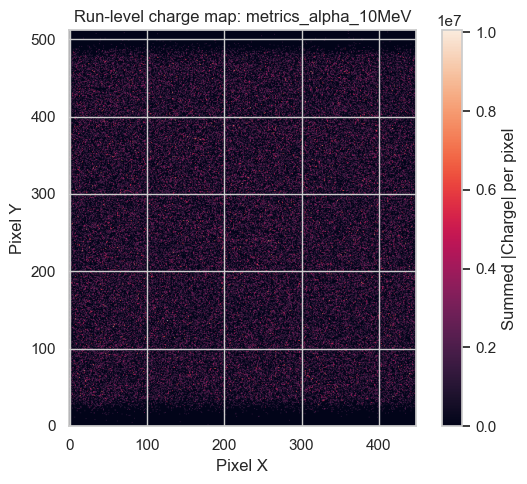

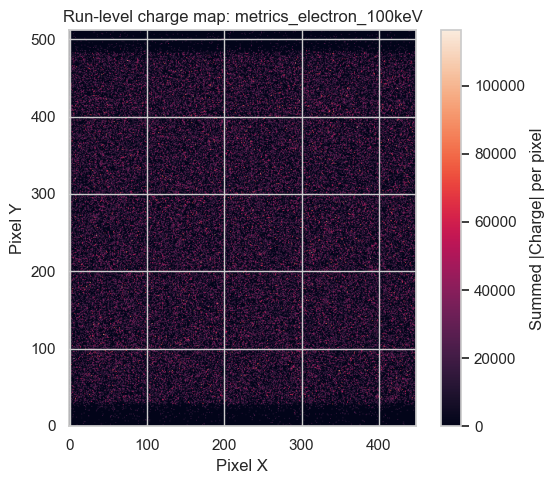

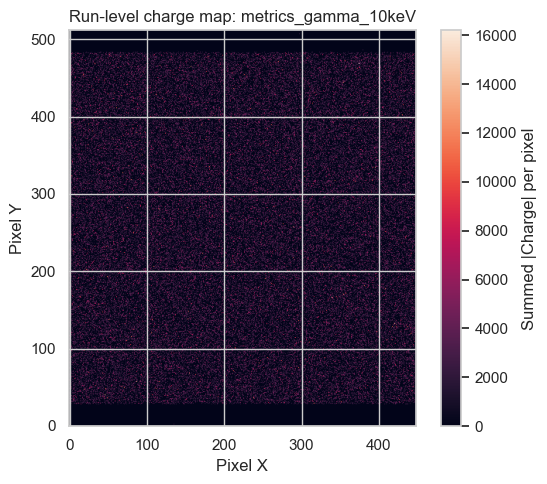

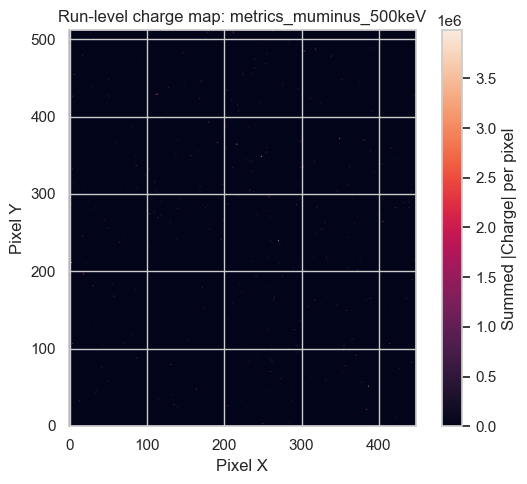

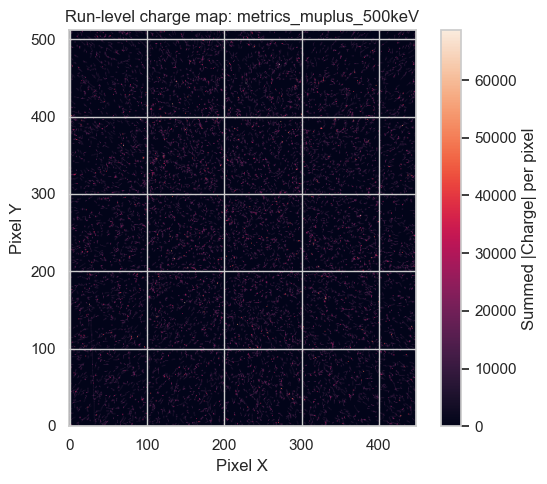

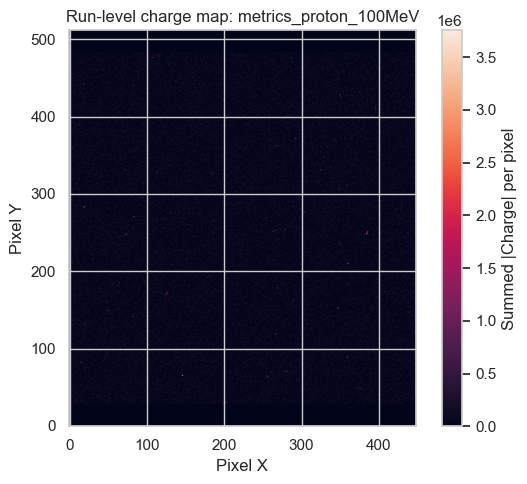

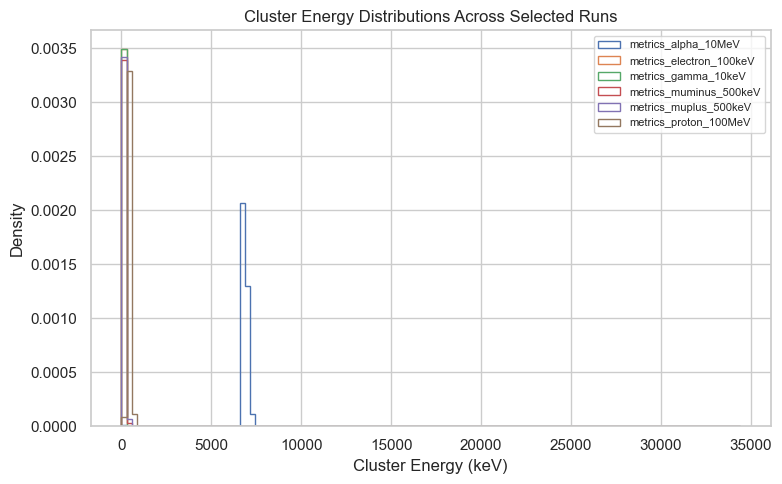

In [10]:
# energy histograms and pixel hit maps (RUN-LEVEL)

metrics_dir = Path("./metrics") #again just in case

CHARGE_COL = "E_cluster_keV"   # cluster-level charge proxy

BINS = 120
HIST_DENSITY = True
HIST_LOGY = False
MAX_RUNS_TO_PLOT = None

# selected runs from earlier
selected_runs = sorted(data["run"].unique())
if MAX_RUNS_TO_PLOT is not None:
    selected_runs = selected_runs[:MAX_RUNS_TO_PLOT]

print(f"Selected runs ({len(selected_runs)}):")
for r in selected_runs[:20]:
    print(" ", r)

# load and plot charge maps
run_hit_maps = {}

for run in selected_runs:
    h5_path = metrics_dir / f"{run}.h5"

    if not h5_path.exists():
        print(f"WARNING: Missing HDF5 for run '{run}'")
        continue

    with h5py.File(h5_path, "r") as f:
        if "run_hit_map" not in f:
            print(f"WARNING: '{run}' has no 'run_hit_map'")
            continue
        run_hit_maps[run] = f["run_hit_map"][:]

# plot one map per run
for run, hit_map in run_hit_maps.items():
    plt.figure(figsize=(6, 5))
    plt.imshow(hit_map, origin="lower", aspect="equal")
    plt.colorbar(label="Summed |Charge| per pixel")
    plt.title(f"Run-level charge map: {run}")
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")
    plt.tight_layout()
    plt.show()

# charge histograms
if CHARGE_COL not in data.columns:
    print(f"WARNING: '{CHARGE_COL}' not found in data.columns")
else:
    plt.figure(figsize=(8, 5))

    vals_all = data[CHARGE_COL].to_numpy()
    vals_all = vals_all[np.isfinite(vals_all)]
    bin_edges = np.histogram_bin_edges(vals_all, bins=BINS)

    for run in selected_runs:
        run_vals = data.loc[data["run"] == run, CHARGE_COL].to_numpy()
        run_vals = run_vals[np.isfinite(run_vals)]
        if len(run_vals) == 0:
            continue

        plt.hist(run_vals,
                 bins=bin_edges,
                 histtype="step",
                 density=HIST_DENSITY,
                 label=run)

    plt.xlabel("Cluster Energy (keV)")
    plt.ylabel("Density" if HIST_DENSITY else "Count")
    plt.title("Cluster Energy Distributions Across Selected Runs")

    if HIST_LOGY:
        plt.yscale("log")

    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
#create plots

sns.set(style="whitegrid")

metrics_to_plot = [
    # size / energy / density
    "n_hits",
    "E_cluster_keV",
    "energy_density",
    "fill_factor",

    # spread / residuals
    "mean_r",
    "rms_r",
    "r90",

    # geometry / footprint
    "size_x",
    "size_y",
    "bbox_area",

    # connectivity
    "neighbor_frac",
]

runs = sorted(data["run"].unique())

for metric in metrics_to_plot:

    if metric not in data.columns:
        print(f"Skipping {metric}")
        continue

    g = sns.displot(
        data=data,
        x=metric,
        col="run",             # one panel per run
        col_wrap=3,            # panels pew row
        bins=50,
        height=3.5,
        aspect=1.1,
        stat="count",          # show counts instead of density
        common_bins=True,
        common_norm=False
    )

    g.fig.suptitle(f"{metric} distribution per run", y=1.03)
    plt.show()



Run-level shape summary (first 20 rows):

Run-level threshold fractions (first 20 rows):

Merged run report (first 20 rows):


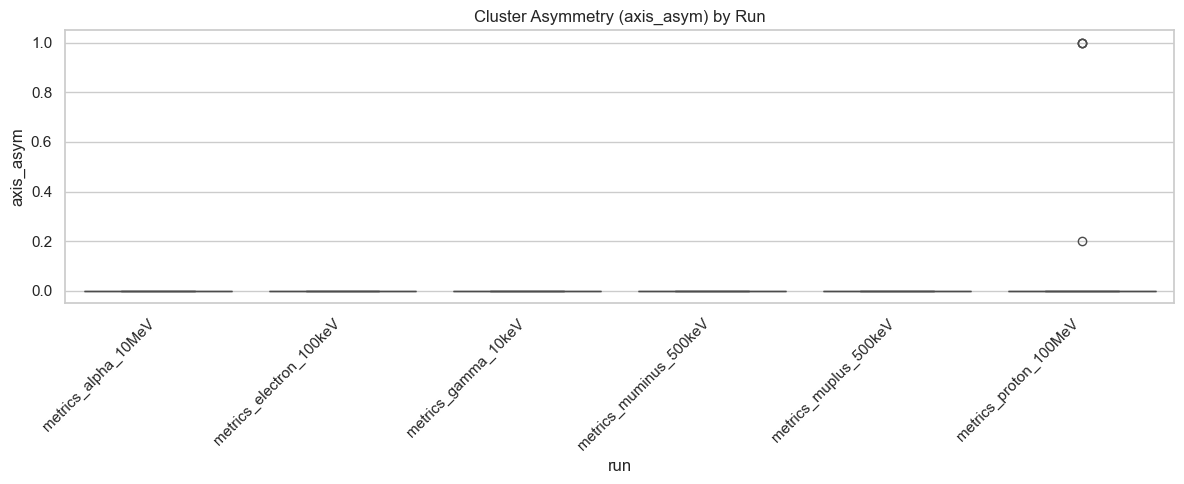

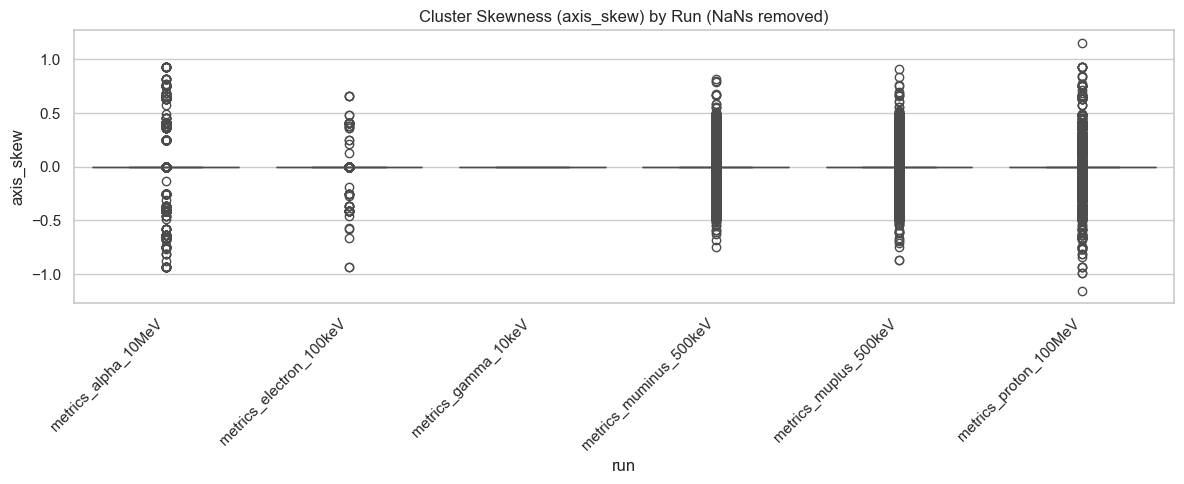

In [11]:

sns.set(style="whitegrid")


# basic cleaning for shape metrics
shape_cols = ["axis_asym", "axis_skew"]
missing = [c for c in shape_cols if c not in data.columns]
if missing:
    raise ValueError(f"Missing required columns in data: {missing}")

# keep a clean view 
dshape = data.copy()

# run-level summary table
run_shape_summary = (
    dshape.groupby(["particle", "energy_keV", "run"], as_index=False)
          .agg(
              n_clusters=("cluster_id", "count"),

              energy_density_median=("energy_density", "median"),
              energy_density_mean=("energy_density", "mean"),

              # --- Core metrics ---
              nhits_median=("n_hits", "median"),
              energy_median=("E_cluster_keV", "median"),
              fill_median=("fill_factor", "median"),

              # --- Spread metrics ---
              mean_r_median=("mean_r", "median"),
              rms_r_median=("rms_r", "median"),
              r90_median=("r90", "median"),

              # --- Geometry metrics ---
              bbox_median=("bbox_area", "median"),
              size_x_median=("size_x", "median"),
              size_y_median=("size_y", "median"),

              # --- Shape metrics ---
              asym_median=("axis_asym", "median"),
              asym_std=("axis_asym", "std"),
              skew_median=("axis_skew", lambda x: np.nanmedian(x)),
              skew_std=("axis_skew", lambda x: np.nanstd(x)),
              skew_nan_rate=("axis_skew", lambda x: float(np.isnan(x).mean())),
          )
)

print("Run-level shape summary (first 20 rows):")
run_shape_summary.sort_values(["particle", "energy_keV", "run"]).head(20)


# fraction above thresholds (interpretable “rates”)
# -----------------------------
# tune these later to typical ranges.
ASYM_THR = 0.30
SKEW_THR = 1.00   # absolute skewness threshold (|skew| > 1)

run_shape_thresholds = (
    dshape.assign(
        high_asym = dshape["axis_asym"] > ASYM_THR,
        high_skew = dshape["axis_skew"].abs() > SKEW_THR
    )
    .groupby(["particle", "energy_keV", "run"], as_index=False)
    .agg(
        frac_high_asym=("high_asym", "mean"),
        frac_high_skew=("high_skew", lambda x: float(np.nanmean(x))),
    )
)

print("\nRun-level threshold fractions (first 20 rows):")
run_shape_thresholds.sort_values(["particle", "energy_keV", "run"]).head(20)

# optional if you want to merge into one convenient table
run_shape_report = pd.merge(
    run_shape_summary,
    run_shape_thresholds,
    on=["particle", "energy_keV", "run"],
    how="left"
)

print("\nMerged run report (first 20 rows):")
run_shape_report.sort_values(["particle", "energy_keV", "run"]).head(20)



# boxplots by run 
# -----------------------------
# Keep runs in a stable order
run_order = (
    run_shape_report.sort_values(["particle", "energy_keV", "run"])["run"]
    .drop_duplicates()
    .tolist()
)

# asymmetry boxplot (axis_asym is usually defined)
plt.figure(figsize=(12, 5))
sns.boxplot(data=dshape, x="run", y="axis_asym", order=run_order)
plt.xticks(rotation=45, ha="right")
plt.title("Cluster Asymmetry (axis_asym) by Run")
plt.tight_layout()
plt.show()

# skewness boxplot (drop NaNs so it plots correctly)
plt.figure(figsize=(12, 5))
sns.boxplot(data=dshape.dropna(subset=["axis_skew"]), x="run", y="axis_skew", order=run_order)
plt.xticks(rotation=45, ha="right")
plt.title("Cluster Skewness (axis_skew) by Run (NaNs removed)")
plt.tight_layout()
plt.show()


In [14]:
#Energy Similarity
from scipy.stats import wasserstein_distance

run_names = sorted(data["run"].unique())

combined_similarity = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
combined_distance = pd.DataFrame(index=run_names, columns=run_names, dtype=float)

energy_distance = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
density_distance = pd.DataFrame(index=run_names, columns=run_names, dtype=float)

# weights
w_energy = 0.5
w_density = 0.5

for run_a in run_names:
    ea = data.loc[data["run"] == run_a, "E_cluster_keV"].to_numpy()
    ea = ea[np.isfinite(ea)]

    da = data.loc[data["run"] == run_a, "energy_density"].to_numpy()
    da = da[np.isfinite(da)]

    for run_b in run_names:
        eb = data.loc[data["run"] == run_b, "E_cluster_keV"].to_numpy()
        eb = eb[np.isfinite(eb)]

        db = data.loc[data["run"] == run_b, "energy_density"].to_numpy()
        db = db[np.isfinite(db)]

        if len(ea) == 0 or len(eb) == 0 or len(da) == 0 or len(db) == 0:
            dE = np.nan
            dD = np.nan
            d_total = np.nan
            sim = np.nan
        else:
            # pairwise scaling for energy
            scale_E = np.std(np.concatenate([ea, eb]))
            if scale_E == 0 or not np.isfinite(scale_E):
                scale_E = 1.0

            # pairwise scaling for energy density
            scale_D = np.std(np.concatenate([da, db]))
            if scale_D == 0 or not np.isfinite(scale_D):
                scale_D = 1.0

            dE = wasserstein_distance(ea, eb) / scale_E
            dD = wasserstein_distance(da, db) / scale_D

            d_total = w_energy * dE + w_density * dD
            sim = 1.0 / (1.0 + d_total)

        energy_distance.loc[run_a, run_b] = dE
        density_distance.loc[run_a, run_b] = dD
        combined_distance.loc[run_a, run_b] = d_total
        combined_similarity.loc[run_a, run_b] = sim

print("Combined energy + energy density similarity matrix:")
display(combined_similarity)

Combined energy + energy density similarity matrix:


,metrics_alpha_10MeV,metrics_electron_100keV,metrics_gamma_10keV,metrics_muminus_500keV,metrics_muplus_500keV,metrics_proton_100MeV
metrics_alpha_10MeV,1.000000,0.353875,0.354058,0.310059,0.273418,0.356165
metrics_electron_100keV,0.353875,1.000000,0.384044,0.681023,0.501163,0.433636
metrics_gamma_10keV,0.354058,0.384044,1.000000,0.710544,0.270992,0.411959
metrics_muminus_500keV,0.310059,0.681023,0.710544,1.000000,0.831804,0.461403
metrics_muplus_500keV,0.273418,0.501163,0.270992,0.831804,1.000000,0.444808
metrics_proton_100MeV,0.356165,0.433636,0.411959,0.461403,0.444808,1.000000


In [15]:
# Geometric similarity
from scipy.stats import wasserstein_distance

geom_metrics = [
    "n_hits",
    "bbox_area",
    "fill_factor",
    "r90",
    "axis_asym",
    "neighbor_frac",
]

run_names = sorted(data["run"].unique())

geometry_similarity = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
geometry_distance = pd.DataFrame(index=run_names, columns=run_names, dtype=float)

geometry_metric_distances = {}
for m in geom_metrics:
    geometry_metric_distances[m] = pd.DataFrame(index=run_names, columns=run_names, dtype=float)

for run_a in run_names:
    run_a_df = data[data["run"] == run_a]

    for run_b in run_names:
        run_b_df = data[data["run"] == run_b]

        dists = []

        for m in geom_metrics:
            a_vals = run_a_df[m].to_numpy()
            b_vals = run_b_df[m].to_numpy()

            a_vals = a_vals[np.isfinite(a_vals)]
            b_vals = b_vals[np.isfinite(b_vals)]

            if len(a_vals) == 0 or len(b_vals) == 0:
                d_m = np.nan
            else:
                pair_scale = np.std(np.concatenate([a_vals, b_vals]))
                if pair_scale == 0 or not np.isfinite(pair_scale):
                    pair_scale = 1.0

                d_m = wasserstein_distance(a_vals, b_vals) / pair_scale

            geometry_metric_distances[m].loc[run_a, run_b] = d_m

            if np.isfinite(d_m):
                dists.append(d_m)

        if len(dists) == 0:
            dist = np.nan
            sim = np.nan
        else:
            dist = np.mean(dists)
            sim = 1.0 / (1.0 + dist)

        geometry_distance.loc[run_a, run_b] = dist
        geometry_similarity.loc[run_a, run_b] = sim

print("Geometry similarity matrix:")
display(geometry_similarity)

Geometry similarity matrix:


,metrics_alpha_10MeV,metrics_electron_100keV,metrics_gamma_10keV,metrics_muminus_500keV,metrics_muplus_500keV,metrics_proton_100MeV
metrics_alpha_10MeV,1.000000,0.756720,0.484196,0.563988,0.466533,0.755363
metrics_electron_100keV,0.756720,1.000000,0.529239,0.606855,0.436589,0.876679
metrics_gamma_10keV,0.484196,0.529239,1.000000,0.538078,0.356268,0.633216
metrics_muminus_500keV,0.563988,0.606855,0.538078,1.000000,0.606472,0.690961
metrics_muplus_500keV,0.466533,0.436589,0.356268,0.606472,1.000000,0.474698
metrics_proton_100MeV,0.755363,0.876679,0.633216,0.690961,0.474698,1.000000
